In [69]:
import requests
from pathlib import Path
import geopandas as gpd
import zipfile
import matplotlib.pyplot as plt
import requests
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm import tqdm
from matplotlib.patches import Patch

In [47]:
url = "https://www.opengeodata.nrw.de/produkte/geologie/boden/BK/ISLBG200/ISLBG200_EPSG25832_Shape.zip"

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

In [48]:
zip_path = data_dir / "ISLBG200.zip"
if not zip_path.exists():
    print("Downloading ISLBG200...")
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
else:
    print("ZIP already exists")

ZIP already exists


In [49]:
with zipfile.ZipFile(zip_path) as z:
    shp_files = [f for f in z.namelist() if f.endswith(".shp")]
    print(shp_files)

['Shapes/LBG_NRW.shp', 'Shapes/ohne_BL__ohne_LBG.shp']


In [50]:
# pick the layers you found
layer_lbg = "Shapes/LBG_NRW.shp"

In [51]:
# read both layers from the zip
gdf_lbg = gpd.read_file(f"zip://{zip_path}!{layer_lbg}")

print("LBG_NRW rows:", len(gdf_lbg))
print("CRS LBG:", gdf_lbg.crs)

LBG_NRW rows: 10082
CRS LBG: EPSG:25832


In [52]:
# 1) Download DVG1 (administrative boundaries) from OpenGeodata NRW
dvg_url = "https://www.opengeodata.nrw.de/produkte/geobasis/vkg/dvg/dvg1/dvg1_EPSG25832_Shape.zip"
dvg_zip_path = data_dir / "dvg1.zip"

In [53]:
if not dvg_zip_path.exists():
    print("Downloading DVG1...")
    r = requests.get(dvg_url, stream=True)
    r.raise_for_status()
    with open(dvg_zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
else:
    print("DVG1 ZIP already exists")


DVG1 ZIP already exists


In [54]:
# 2) Inspect shapefiles inside DVG1 zip
with zipfile.ZipFile(dvg_zip_path) as z:
    dvg_shps = [f for f in z.namelist() if f.endswith(".shp")]
    print("DVG shapefiles:", dvg_shps)

DVG shapefiles: ['dvg1bld_nw.shp', 'dvg1gem_nw.shp', 'dvg1gem_nw_o.shp', 'dvg1krs_nw.shp', 'dvg1rbz_nw.shp']


RBZ columns: ['ART', 'GN', 'KN', 'STAND', 'geometry']
GN sample: ['Arnsberg' 'Detmold' 'Düsseldorf' 'Köln' 'Münster']


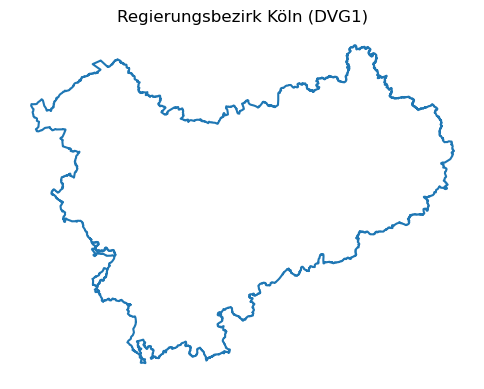

In [55]:
# --- use Regierungsbezirk layer instead of Gemeinden ---
dvg_layer = "dvg1rbz_nw.shp"
dvg_rbz = gpd.read_file(f"zip://{dvg_zip_path}!{dvg_layer}")

print("RBZ columns:", list(dvg_rbz.columns))

# GN contains the name of the Regierungsbezirk
print("GN sample:", dvg_rbz["GN"].unique())

# Filter Regierungsbezirk Köln
koeln_rbz = dvg_rbz[
    dvg_rbz["GN"].fillna("").str.contains(r"\bKöln\b|\bKoeln\b", case=False, regex=True)
].copy()

if koeln_rbz.empty:
    raise ValueError("Regierungsbezirk Köln not found in dvg1rbz_nw.shp")

# Dissolve to a single polygon and ensure CRS
koeln_rbz = koeln_rbz.to_crs(25832).dissolve()

# Plot the district outline
ax = koeln_rbz.boundary.plot(figsize=(6, 6))
ax.set_title("Regierungsbezirk Köln (DVG1)")
ax.axis("off")
plt.show()

In [56]:
# --- clip the soil layers with Regierungsbezirk Köln ---

# make sure CRS matches
gdf_lbg = gdf_lbg.to_crs(25832)

# clip
gdf_lbg_koeln = gpd.clip(gdf_lbg, koeln_rbz)

print("Clipped LBG rows:", len(gdf_lbg_koeln))

Clipped LBG rows: 2169


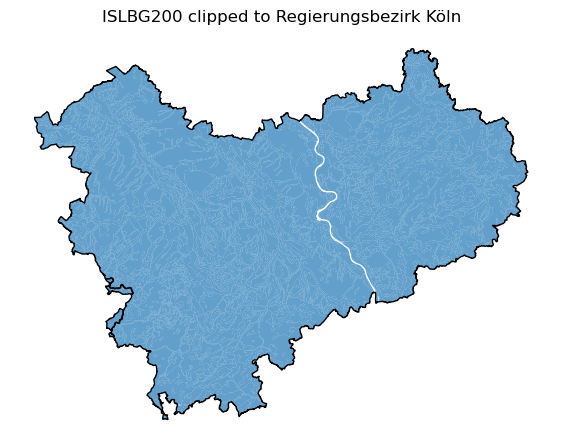

In [57]:
fig, ax = plt.subplots(figsize=(7, 7))

koeln_rbz.boundary.plot(ax=ax, color="black", linewidth=1)
gdf_lbg_koeln.plot(ax=ax, linewidth=0.2, alpha=0.7)

ax.set_title("ISLBG200 clipped to Regierungsbezirk Köln")
ax.axis("off")
plt.show()

In [58]:
# --- Nature protected areas (LINFOS) : download, read, clip, plot overlay ---

linfos_url = "https://www.opengeodata.nrw.de/produkte/umwelt_klima/naturschutz/linfos/BereicheSchutzNatur_EPSG25832_Shape.zip"
linfos_zip = data_dir / "BereicheSchutzNatur.zip"

# download (programmatic, reproducible)
if not linfos_zip.exists():
    print("Downloading Bereiche für den Schutz der Natur (LINFOS)...")
    r = requests.get(linfos_url, stream=True)
    r.raise_for_status()
    with open(linfos_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
else:
    print("LINFOS ZIP already exists")

LINFOS ZIP already exists


BSN clipped rows: 557


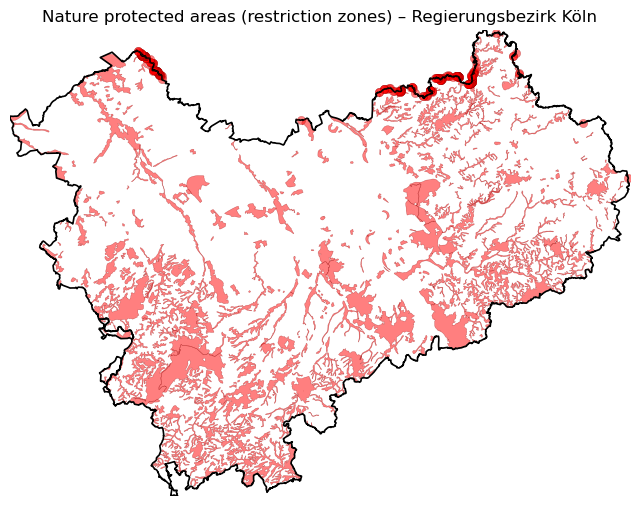

In [59]:
# read the first .shp inside the zip
with zipfile.ZipFile(linfos_zip) as z:
    shp = [p for p in z.namelist() if p.endswith(".shp")][0]

bsn = gpd.read_file(f"zip://{linfos_zip}!{shp}").to_crs(25832)

# clip to your study area (Regierungsbezirk Köln)
bsn_koeln = gpd.clip(bsn, koeln_rbz)
print("BSN clipped rows:", len(bsn_koeln))

# --- plot with protected areas highlighted in red ---

fig, ax = plt.subplots(figsize=(8, 8))

# force extent to AOI
minx, miny, maxx, maxy = koeln_rbz.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# AOI outline
koeln_rbz.boundary.plot(ax=ax, color="black", linewidth=1.2)

# protected areas = restriction (red)
bsn_koeln.plot(
    ax=ax,
    color="red",
    alpha=0.5,
    edgecolor="darkred",
    linewidth=0.3
)

ax.set_title("Nature protected areas (restriction zones) – Regierungsbezirk Köln")
ax.axis("off")
plt.show()

In [60]:
# --- Bird protected areas (Vogelschutzgebiete) : download, read, clip, plot overlay ---

vsg_url = "https://www.opengeodata.nrw.de/produkte/umwelt_klima/naturschutz/linfos/Vogelschutzgebiete_EPSG25832_Shape.zip"
vsg_zip = data_dir / "Vogelschutzgebiete.zip"

# download
if not vsg_zip.exists():
    print("Downloading Vogelschutzgebiete (LINFOS)...")
    r = requests.get(vsg_url, stream=True)
    r.raise_for_status()
    with open(vsg_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
else:
    print("Vogelschutzgebiete ZIP already exists")


Vogelschutzgebiete ZIP already exists


Vogelschutzgebiete clipped rows: 8


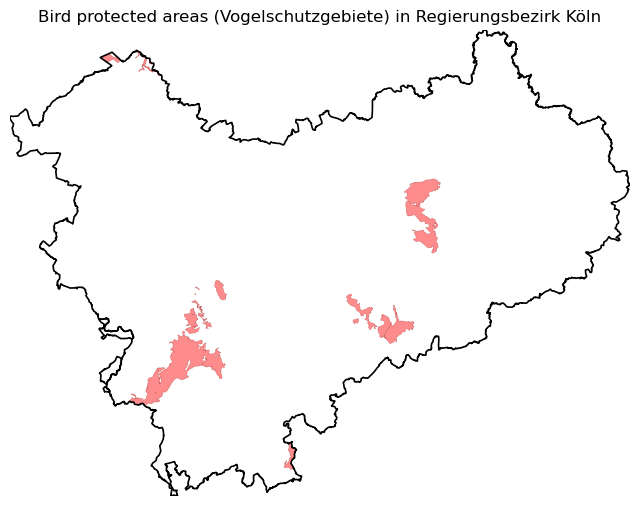

In [61]:
# read shapefile inside zip
with zipfile.ZipFile(vsg_zip) as z:
    vsg_shp = [p for p in z.namelist() if p.endswith(".shp")][0]
    # optional: print all shps if you want to be explicit
    # print([p for p in z.namelist() if p.endswith(".shp")])

vsg = gpd.read_file(f"zip://{vsg_zip}!{vsg_shp}").to_crs(25832)

# clip to study area
vsg_koeln = gpd.clip(vsg, koeln_rbz)
print("Vogelschutzgebiete clipped rows:", len(vsg_koeln))

# plot overlay (bird protected areas in red)
fig, ax = plt.subplots(figsize=(8, 8))

# force extent to AOI
minx, miny, maxx, maxy = koeln_rbz.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# AOI outline
koeln_rbz.boundary.plot(ax=ax, color="black", linewidth=1.2)

# bird protected areas = restriction (red)
vsg_koeln.plot(
    ax=ax,
    color="#ff0000",
    alpha=0.45,
    edgecolor="#8b0000",
    linewidth=0.3
)

ax.set_title("Bird protected areas (Vogelschutzgebiete) in Regierungsbezirk Köln")
ax.axis("off")
plt.show()

Nature only parts: 1
Bird only parts: 1
Both overlap parts: 1


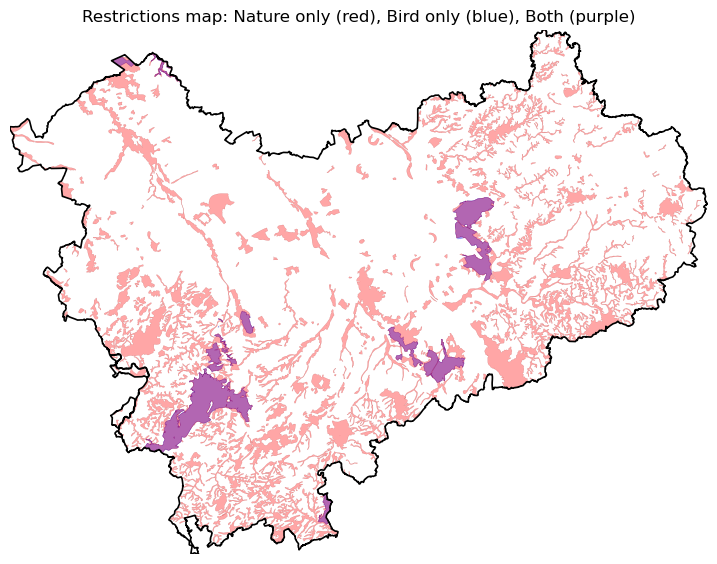

In [62]:
# Make sure both are polygons, valid, same CRS
vsg_koeln = vsg_koeln.to_crs(25832)
bsn_koeln = bsn_koeln.to_crs(25832)

# dissolve to reduce complexity (recommended before overlays)
vsg_dis = vsg_koeln.dissolve()
bsn_dis = bsn_koeln.dissolve()

# fix invalid geometries (helps overlay operations)
vsg_dis["geometry"] = vsg_dis.geometry.buffer(0)
bsn_dis["geometry"] = bsn_dis.geometry.buffer(0)

# intersection = overlap of both restrictions
both = gpd.overlay(bsn_dis, vsg_dis, how="intersection")

# nature only = nature minus birds
nature_only = gpd.overlay(bsn_dis, vsg_dis, how="difference")

# bird only = birds minus nature
bird_only = gpd.overlay(vsg_dis, bsn_dis, how="difference")

print("Nature only parts:", len(nature_only))
print("Bird only parts:", len(bird_only))
print("Both overlap parts:", len(both))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 9))
minx, miny, maxx, maxy = koeln_rbz.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

koeln_rbz.boundary.plot(ax=ax, color="black", linewidth=1.2)

# order: base layers first, overlap last
if not nature_only.empty:
    nature_only.plot(ax=ax, color="red", alpha=0.35, edgecolor="darkred", linewidth=0.2)

if not bird_only.empty:
    bird_only.plot(ax=ax, color="blue", alpha=0.35, edgecolor="darkblue", linewidth=0.2)

if not both.empty:
    both.plot(ax=ax, color="purple", alpha=0.6, edgecolor="purple", linewidth=0.3)

ax.set_title("Restrictions map: Nature only (red), Bird only (blue), Both (purple)")
ax.axis("off")
plt.show()

DLM50 ZIP already exists.
Rows in full NRW layer:
  AX_Siedlungsflaeche (41010): 296175
  AX_IndustrieUndGewerbeflaeche (41002): 37178
Rows in AOI:
  Siedlungsflaeche: 63076
  Industrie/Gewerbe: 7950


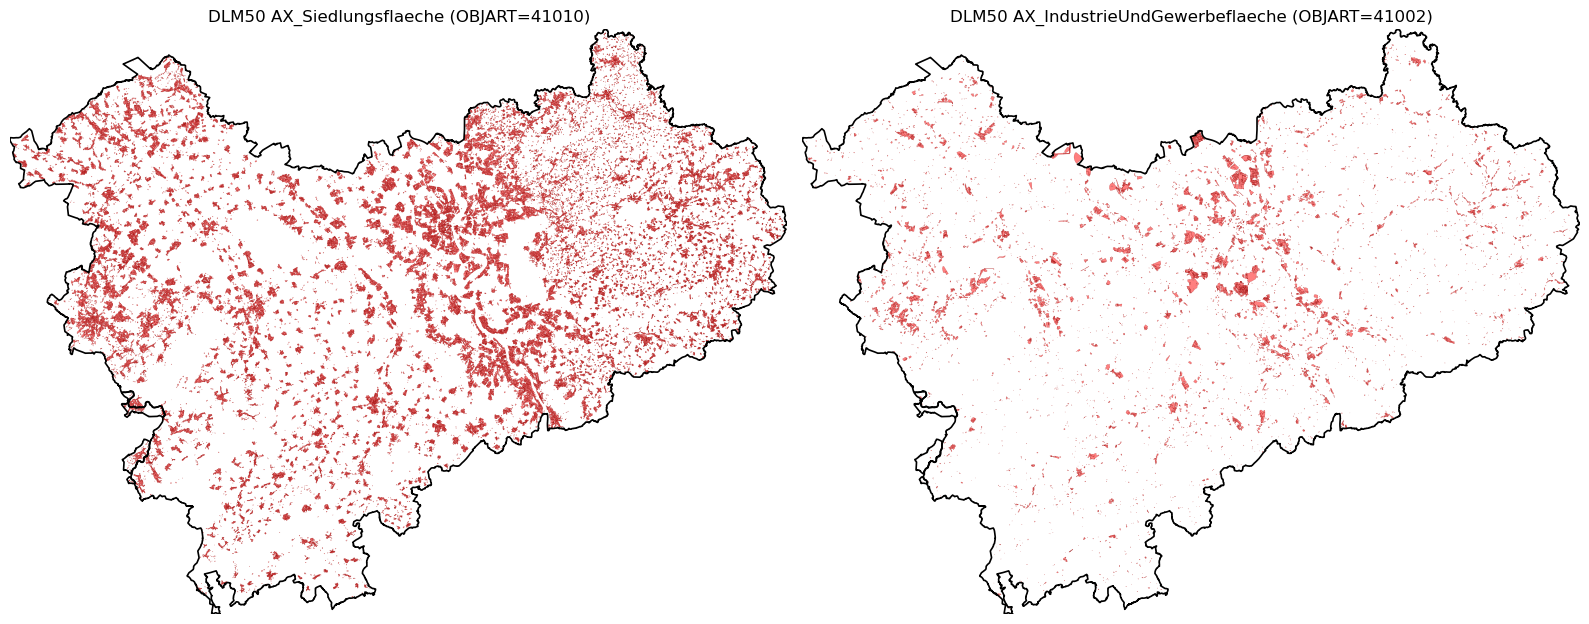

In [63]:
# -------------------------------------------------------------------
# Inputs
# -------------------------------------------------------------------
dlm50_url = "https://www.opengeodata.nrw.de/produkte/geobasis/lm/akt/dlm50/dlm50_EPSG25832_Shape.zip"
dlm50_zip = Path(r"C:\Users\Laura\wsa\notebooks\data\dlm50_EPSG25832_Shape.zip")

# AOI must exist
if "koeln_rbz" not in globals():
    raise NameError("koeln_rbz is not defined. Load/create your AOI first.")
koeln_rbz = koeln_rbz.to_crs(25832)

# Known codes (from the keys file)
CODE_SIEDLUNGSFLAECHE = "41010"
CODE_INDUSTRIE_GEWERBE = "41002"

# Correct DLM50 polygon layer (based on your inspection)
BEST_SHP = "sie02_f.shp"

# -------------------------------------------------------------------
# 1) Download once
# -------------------------------------------------------------------
dlm50_zip.parent.mkdir(parents=True, exist_ok=True)
if not dlm50_zip.exists():
    print("Downloading DLM50 ZIP (first time only)...")
    r = requests.get(dlm50_url, stream=True, timeout=180)
    r.raise_for_status()
    with open(dlm50_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
else:
    print("DLM50 ZIP already exists.")

# -------------------------------------------------------------------
# 2) Read the layer directly from the ZIP (no unzip needed)
# -------------------------------------------------------------------
dlm50 = gpd.read_file(f"zip://{dlm50_zip}!{BEST_SHP}")

# Make sure CRS is correct
if dlm50.crs is None:
    dlm50 = dlm50.set_crs(25832)
dlm50 = dlm50.to_crs(25832)

# -------------------------------------------------------------------
# 3) Filter by OBJART codes (robust)
# -------------------------------------------------------------------
objart = dlm50["OBJART"].astype(str).str.strip()

siedlung = dlm50[objart == CODE_SIEDLUNGSFLAECHE].copy()
industrie_gewerbe = dlm50[objart == CODE_INDUSTRIE_GEWERBE].copy()

print("Rows in full NRW layer:")
print("  AX_Siedlungsflaeche (41010):", len(siedlung))
print("  AX_IndustrieUndGewerbeflaeche (41002):", len(industrie_gewerbe))

# -------------------------------------------------------------------
# 4) Clip to AOI
# -------------------------------------------------------------------
siedlung_koeln = gpd.clip(siedlung, koeln_rbz)
ind_koeln = gpd.clip(industrie_gewerbe, koeln_rbz)

print("Rows in AOI:")
print("  Siedlungsflaeche:", len(siedlung_koeln))
print("  Industrie/Gewerbe:", len(ind_koeln))

# -------------------------------------------------------------------
# 5) Plot (avoid empty warnings)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

minx, miny, maxx, maxy = koeln_rbz.total_bounds
for ax in axes:
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    koeln_rbz.boundary.plot(ax=ax, color="black", linewidth=1.2)
    ax.axis("off")

axes[0].set_title("DLM50 AX_Siedlungsflaeche (OBJART=41010)")
axes[1].set_title("DLM50 AX_IndustrieUndGewerbeflaeche (OBJART=41002)")

if not siedlung_koeln.empty:
    siedlung_koeln.plot(ax=axes[0], color="red", alpha=0.5, edgecolor="darkred", linewidth=0.2)
else:
    axes[0].text(0.5, 0.5, "No settlement features in AOI", ha="center", va="center", transform=axes[0].transAxes)

if not ind_koeln.empty:
    ind_koeln.plot(ax=axes[1], color="red", alpha=0.5, edgecolor="darkred", linewidth=0.2)
else:
    axes[1].text(0.5, 0.5, "No industry/commercial features in AOI", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

# Optional quick overlap debug if AOI is still empty:
# print("AOI bounds:", koeln_rbz.total_bounds)
# print("DLM50 bounds:", dlm50.total_bounds)

Processing restriction overlays:   0%|                                                         | 0/8 [02:39<?, ?step/s]


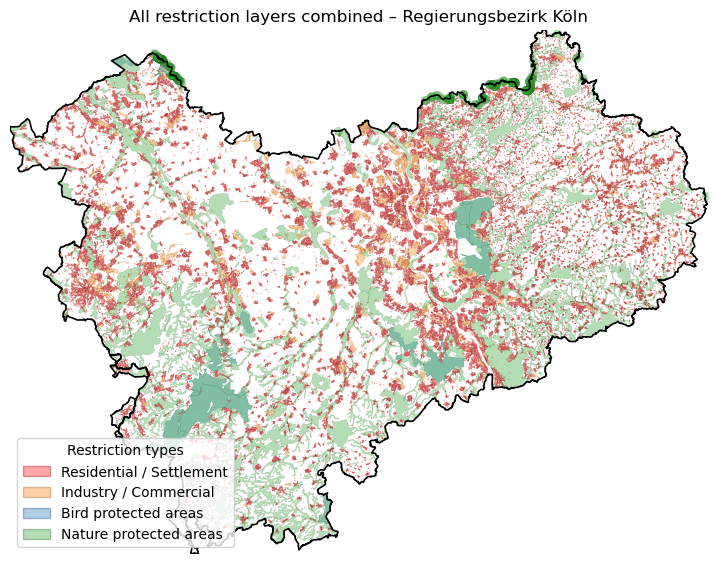

Processing restriction overlays:   0%|                                                         | 0/8 [00:55<?, ?step/s]


In [70]:
# ------------------------------------------------------------
# Progress bar setup
# ------------------------------------------------------------
pbar = tqdm(total=8, desc="Processing restriction overlays", unit="step")

fig, ax = plt.subplots(figsize=(9, 9))

minx, miny, maxx, maxy = koeln_rbz.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# AOI outline
koeln_rbz.boundary.plot(ax=ax, color="black", linewidth=1.2)

# ---- Plot layers (NO labels here) ----
if "siedlung_koeln" in globals() and not siedlung_koeln.empty:
    siedlung_koeln.plot(
        ax=ax, color="#ff0000", alpha=0.35,
        edgecolor="#8b0000", linewidth=0.2
    )

if "ind_koeln" in globals() and not ind_koeln.empty:
    ind_koeln.plot(
        ax=ax, color="#ff7f00", alpha=0.35,
        edgecolor="#a34f00", linewidth=0.2
    )

if "vsg_koeln" in globals() and not vsg_koeln.empty:
    vsg_koeln.plot(
        ax=ax, color="#1f77b4", alpha=0.35,
        edgecolor="#0b3d91", linewidth=0.2
    )

if "bsn_koeln" in globals() and not bsn_koeln.empty:
    bsn_koeln.plot(
        ax=ax, color="#2ca02c", alpha=0.35,
        edgecolor="#145a14", linewidth=0.2
    )

# ------------------------------------------------------------
# Manual legend (THIS is the key fix)
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor="#ff0000", edgecolor="#8b0000", label="Residential / Settlement", alpha=0.35),
    Patch(facecolor="#ff7f00", edgecolor="#a34f00", label="Industry / Commercial", alpha=0.35),
    Patch(facecolor="#1f77b4", edgecolor="#0b3d91", label="Bird protected areas", alpha=0.35),
    Patch(facecolor="#2ca02c", edgecolor="#145a14", label="Nature protected areas", alpha=0.35),
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True,
    title="Restriction types"
)

ax.set_title("All restriction layers combined – Regierungsbezirk Köln")
ax.axis("off")
plt.show()

pbar.close()